In [1]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn import tree


warnings.simplefilter(action = 'ignore', category = FutureWarning)

In [2]:
def wrangle(filepath):
    df = pd.read_csv(filepath)
    
    mask_mhv = df['median_house_value'] < 500000

    df = df[mask_mhv]


    return df

In [3]:
df = wrangle('C:/Users/Admin/TSA/housing.csv')
print(df.shape)
df.head()

(19648, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19648 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           19648 non-null  float64
 1   latitude            19648 non-null  float64
 2   housing_median_age  19648 non-null  float64
 3   total_rooms         19648 non-null  float64
 4   total_bedrooms      19448 non-null  float64
 5   population          19648 non-null  float64
 6   households          19648 non-null  float64
 7   median_income       19648 non-null  float64
 8   median_house_value  19648 non-null  float64
 9   ocean_proximity     19648 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,19648.000000,19648.000000,19648.000000,19648.000000,19448.000000,19648.000000,19648.000000,19648.000000,19648.000000
mean,-119.562378,35.651872,28.373066,2620.337693,539.645825,1441.368485,501.192488,3.676411,192055.328583
std,2.005760,2.150066,12.504050,2182.371939,422.553057,1144.075196,383.391367,1.570602,97110.854998
min,-124.350000,32.540000,1.000000,2.000000,2.000000,3.000000,2.000000,0.499900,14999.000000
25%,-121.760000,33.930000,18.000000,1438.000000,297.000000,796.000000,282.000000,2.526300,116475.000000
50%,-118.500000,34.270000,28.000000,2111.000000,436.000000,1179.000000,411.000000,3.449050,173600.000000
75%,-117.990000,37.730000,37.000000,3121.000000,648.000000,1746.250000,606.000000,4.582500,247900.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,499100.000000


split

In [6]:
features = ['longitude',
            'latitude',
            'housing_median_age',
            'total_rooms',
            'total_bedrooms',
            'population',
            'households',
            'median_income']
X_train = df[features]
print(X_train.shape)

X_train

(19648, 8)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462
...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672


In [7]:
target = 'median_house_value'
y_train = df[target]
print(y_train.shape)
y_train

(19648,)


0        452600.0
1        358500.0
2        352100.0
3        341300.0
4        342200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 19648, dtype: float64

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size = 0.2, random_state = 42)

model training

In [9]:
model = DecisionTreeRegressor(max_depth = 10,
                         min_samples_split= 20,
                         min_samples_leaf= 10,
                             random_state= 42)

model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

evaluation

In [10]:
y_pred_training = model.predict(X_train)
y_pred_training[:5]

array([114952.02312139, 208130.        , 264030.        , 148821.50537634,
       353643.47826087])

In [11]:
result_df = pd.DataFrame({'Actual' : y_train, 'Predicted' : y_pred_training})
display(result_df)

,Actual,Predicted
12794,67000.0,114952.023121
14570,162500.0,208130.000000
9328,290800.0,264030.000000
5102,131700.0,148821.505376
1822,401000.0,353643.478261
...,...,...
11877,123800.0,104154.729730
12563,92700.0,121786.075949
5631,146900.0,148821.505376
870,300000.0,275168.292683


In [12]:
y_pred_test = model.predict(X_test)
y_pred_test[:5]

array([379223.52941176, 286177.5862069 , 178120.        , 209904.31211499,
       394420.83333333])

In [13]:
result_df = pd.DataFrame({'Actual' : y_test, 'Predicted' : y_pred_test})
result_df

,Actual,Predicted
8979,329800.0,379223.529412
17945,294700.0,286177.586207
17356,195700.0,178120.000000
3378,161500.0,209904.312115
15797,275000.0,394420.833333
...,...,...
15728,418400.0,394420.833333
9448,96000.0,113887.500000
54,87500.0,123544.270833
8095,138100.0,147330.000000


In [14]:
average_price = df['median_house_value'].mean()
average_price

192055.3285830619

In [15]:
MAE_training = mean_absolute_error(y_train, y_pred_training)
percentage_training_error = (MAE_training / average_price) * 100

r2_training = r2_score(y_train, y_pred_training)


MAE_test = mean_absolute_error(y_test, y_pred_test)
percentage_test_error = (MAE_test / average_price) * 100

r2_test = r2_score(y_test, y_pred_test)


In [16]:
print('MAE_training:', round( percentage_training_error, 2))
print('MAE_test:', round(percentage_test_error, 2))
print('r2_training:', round( r2_training, 4) )
print('r2_test:', round( r2_training, 4) )

MAE_training: 16.36
MAE_test: 19.36
r2_training: 0.7859
r2_test: 0.7859


feature importance

In [17]:
feature_imp = pd.DataFrame({'features' : X_train.columns,
                            'importance' : model.feature_importances_}).sort_values('importance', ascending = True)

feature_imp
                            

,features,importance
6,households,0.005941
4,total_bedrooms,0.006020
5,population,0.009576
3,total_rooms,0.011238
2,housing_median_age,0.036995
1,latitude,0.176567
0,longitude,0.215359
7,median_income,0.538305


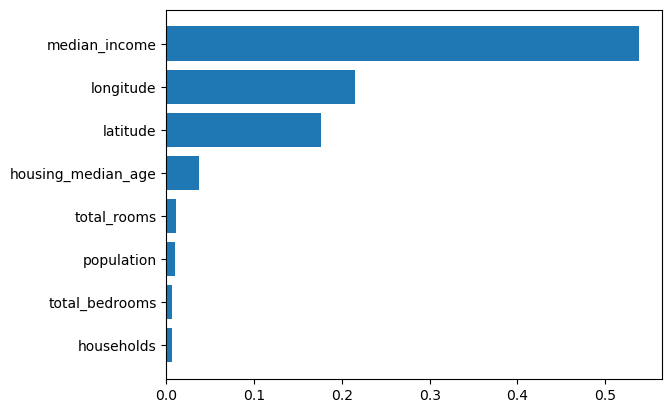

In [18]:

plt.barh(data = feature_imp, y = 'features', width = 'importance')
plt.show()

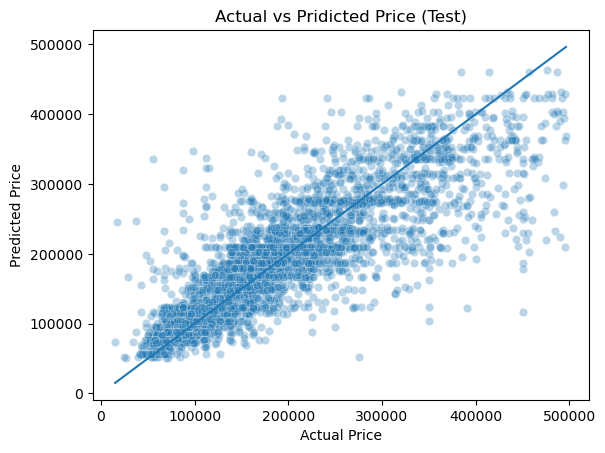

In [19]:
sns.scatterplot(data = result_df, x = y_test, y = y_pred_test, alpha = 0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Pridicted Price (Test)')
plt.show()

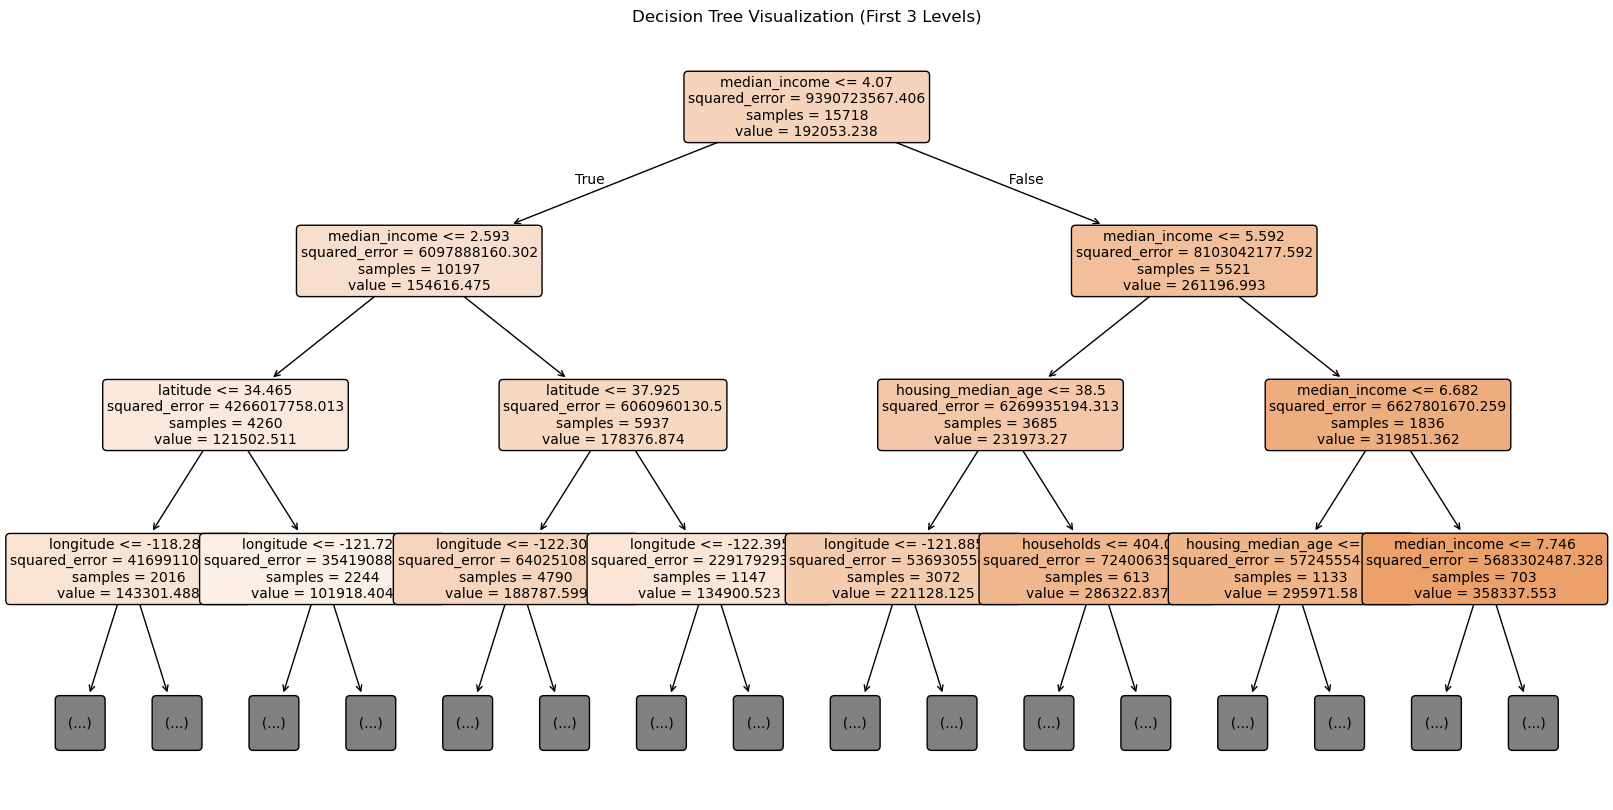

In [20]:
plt.figure(figsize=(20, 10))
tree.plot_tree(model, max_depth= 3,
               feature_names= features,
               filled = True,
               fontsize = 10,
               rounded = True
       
              )

plt.title('Decision Tree Visualization (First 3 Levels)')

plt.show()

Random Forest Regression¶

In [22]:
from sklearn.ensemble import RandomForestRegressor

In [23]:
model = RandomForestRegressor(n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1)


model.fit(X_train, y_train)
                              

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Evaluation

In [25]:
y_pred_training = model.predict(X_train)
y_pred_training[:5]

array([ 92544.23829537, 206340.88686919, 266449.93272484, 164748.66069568,
       367463.03654371])

In [27]:
result_df = pd.DataFrame({'Actual' : y_train, 'Predicted' : y_pred_training})
display(result_df.head())

,Actual,Predicted
12794,67000.0,92544.238295
14570,162500.0,206340.886869
9328,290800.0,266449.932725
5102,131700.0,164748.660696
1822,401000.0,367463.036544


In [28]:
y_pred_test = model.predict(X_test)
y_pred_test[:5]

array([342757.64076195, 255865.3366636 , 206214.99362385, 210003.0443151 ,
       376182.3253249 ])

In [29]:
result_df = pd.DataFrame({'Actual' : y_test, 'Predicted' : y_pred_test})
display(result_df.head())

,Actual,Predicted
8979,329800.0,342757.640762
17945,294700.0,255865.336664
17356,195700.0,206214.993624
3378,161500.0,210003.044315
15797,275000.0,376182.325325


Metrics

In [30]:
MAE_training = mean_absolute_error(y_train, y_pred_training)
percentage_error = (MAE_training / average_price) * 100

MAE_test = mean_absolute_error(y_test, y_pred_test)
percentage_error_test = (MAE_test / average_price) * 100

r2_training = r2_score(y_train, y_pred_training)

r2_test = r2_score(y_test, y_pred_test)

In [31]:
print('MAE_training:', round(percentage_error, 2))
print('MAE_test:', round(percentage_error_test, 2))

print('r2_training:', round(r2_training, 2))
print('r2_test:', round(r2_test, 2))


MAE_training: 15.25
MAE_test: 17.78
r2_training: 0.81
r2_test: 0.75


Feature Importance

In [45]:
feature_imp = pd.DataFrame({'feature' : features, 'importance' : model.feature_importances_}).sort_values('importance', ascending = True)
feature_imp


,feature,importance
6,households,0.007388
4,total_bedrooms,0.012267
3,total_rooms,0.012483
5,population,0.014473
2,housing_median_age,0.046563
1,latitude,0.167882
0,longitude,0.198862
7,median_income,0.540082


horizontal barchart

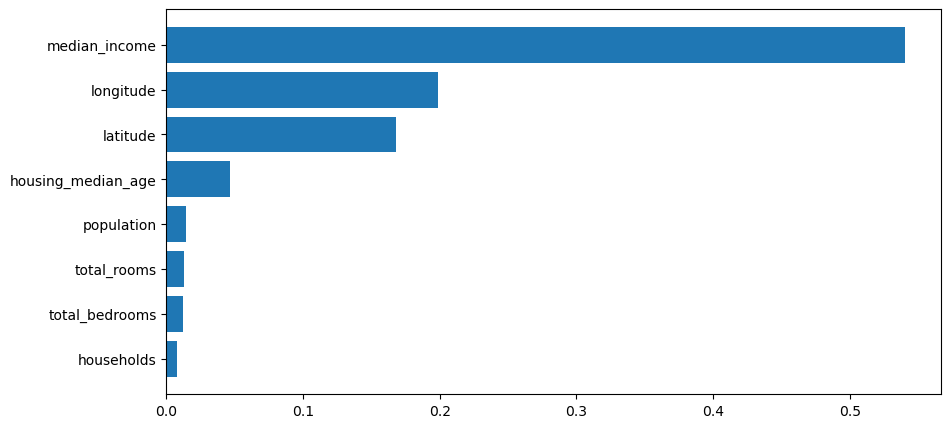

In [46]:
plt.figure(figsize = (10, 5))
plt.barh(data = feature_imp, y = 'feature',  width = 'importance')
plt.show()

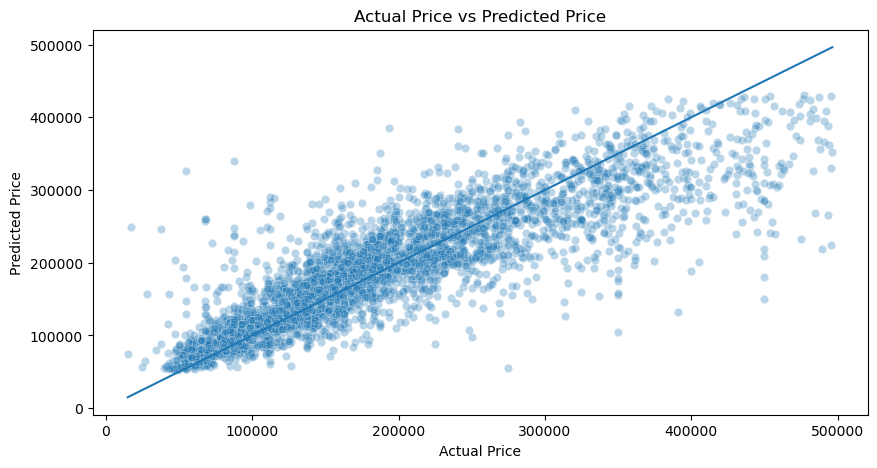

In [52]:
plt.figure(figsize = (10, 5))
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
sns.scatterplot(data = result_df, x = y_test, y = y_pred_test, alpha = 0.3)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual Price vs Predicted Price')
plt.show()

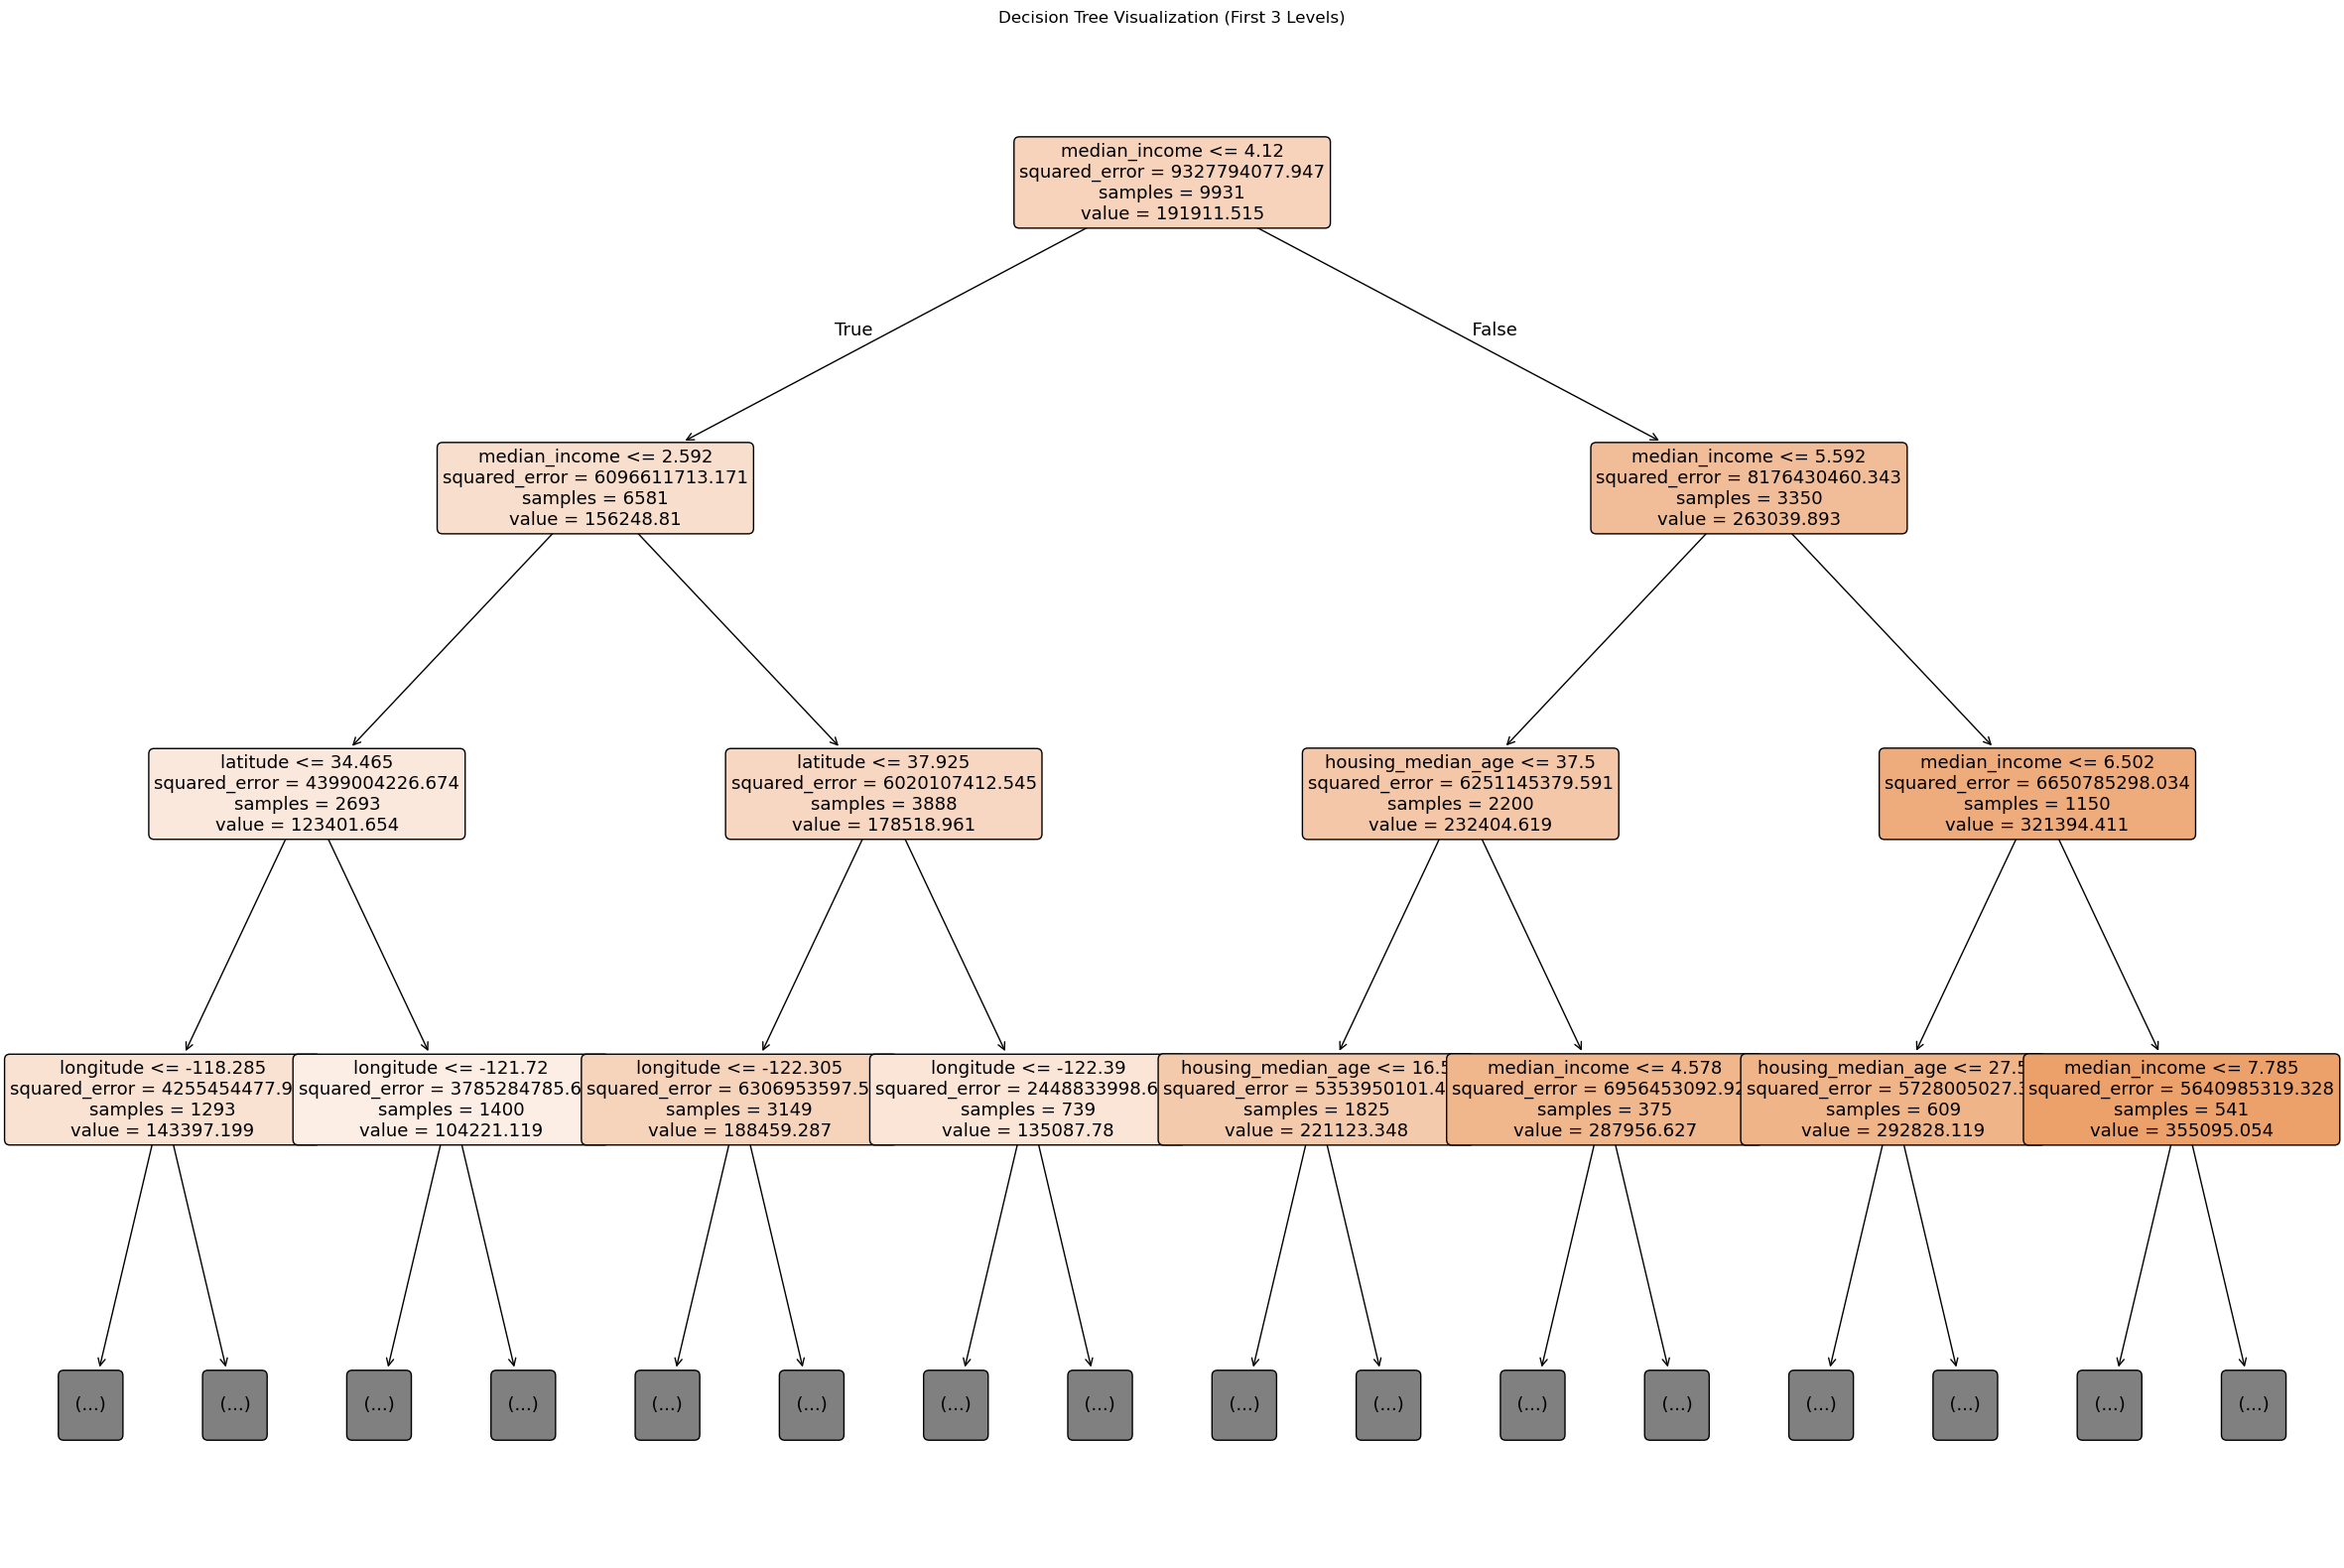

In [65]:
plt.figure(figsize = (30, 20))
tree.plot_tree(decision_tree = model.estimators_[0],    
    max_depth=3,
    feature_names= features,
    filled=True,
               rounded=True,
               fontsize = 13)
plt.title('Decision Tree Visualization (First 3 Levels)')

plt.show()
           